## 필요 함수 import

In [14]:
import pandas as pd
import numpy as np
from sklearn.tree import export_graphviz
import graphviz

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, auc, roc_curve

from models import *

In [2]:
# 한글 폰트 깨지지 않게 하기
plt.rc('font', family='Malgun Gothic')  # Windows
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

## 데이터 불러오기 및 정제

In [16]:
df = pd.read_csv("../B1_data/preprocessing_data/final_data.csv")
df.drop(columns = ['etching_velo', 'kperna'], inplace = True)
df.head()

,type,Temp_OXid,ppm,Pressure,Oxid_time,N2_HMDS,pressure_HMDS,temp_HMDS,time_HMDS_bake,spin1,...,time_softbake,Energy_Exposure,Source_Power,Temp_Etching,max_flux,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,y_label
0,dry,1214.33,26.78,0.30,120,17.362,15.112,19.893,89.963,502.276,...,29.911,109.653,52.080,72.628,6.470000e+17,30795.856,103.513,854.0,154,0
1,dry,977.98,30.90,0.14,137,16.015,15.083,20.035,89.988,507.132,...,30.004,104.946,52.028,70.220,1.040000e+18,32135.659,105.628,895.0,156,0
2,dry,1175.95,31.11,0.25,116,19.229,14.917,19.884,89.918,501.579,...,30.037,106.563,50.705,71.140,6.470000e+17,31057.876,102.716,898.0,152,0
3,dry,933.47,31.20,0.29,143,18.894,14.886,20.023,90.094,503.475,...,30.037,108.696,51.550,71.306,3.410000e+17,32140.435,102.902,879.0,155,0
4,wet,1140.60,31.38,0.20,76,13.851,14.705,20.000,90.070,501.384,...,30.087,109.944,50.681,72.982,7.260000e+17,31985.989,101.465,882.0,155,0


In [17]:
df = pd.get_dummies(df)
x = df.drop('y_label', axis = 1)
y = df['y_label']

df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(x,y,test_size = 0.3, random_state=1986)

In [18]:
def print_metric(y_true, y_pred, y_pred_proba, data_name): # 실제값, 예측값, ROC 커브이미지 저장이름 ex)RF-train
    cm = confusion_matrix(y_true, y_pred)
    TP = cm[1][1]
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1_score = 2 * (precision * recall) / (precision + recall)
    specificity = TN / (TN + FP)

    metric_list = [accuracy, precision,recall, f1_score, specificity]
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
    plt.legend(loc="lower right")
    plt.ylabel("TPR"); plt.xlabel("FPR")
    plt.savefig(data_name+"_roc_curve.png")
    plt.show()
    print(cm)
    return pd.DataFrame(metric_list, index=['Accuracy', 'Precision', 'Recall', 'F1_score', 'Specificity'])


## Gradient Boosting 모델

Score on training set: 0.976
Score on test set: 0.968


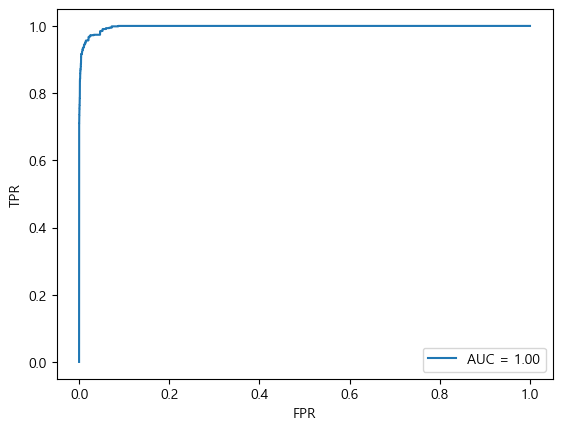

[[9610    1]
 [ 251  509]]


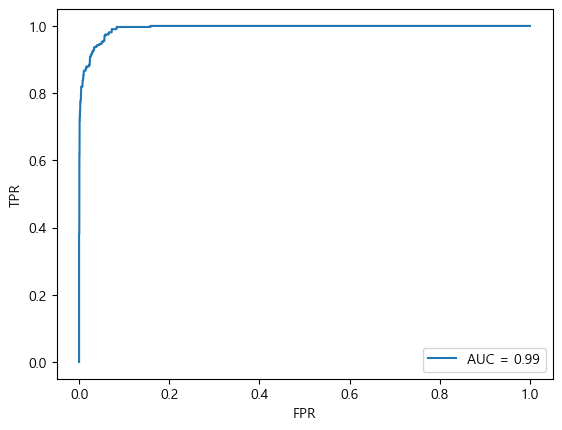

[[4128    2]
 [ 140  175]]
             gb_train   gb_test
Accuracy     0.975701  0.968054
Precision    0.998039  0.988701
Recall       0.669737  0.555556
F1_score     0.801575  0.711382
Specificity  0.999896  0.999516


In [19]:
'''
디폴트 값으로 정의된 모델을 기반으로 학습했을때,
학습 데이터나 테스트 데이터셋에 대해 성능차이가 거의 없으며, 잘 학습된 모습을 보인다.

파라미터의 조정 이후에도 성능을 계속 유지하거나 더 좋은 성능을 보이는지 확인해보도록 하겠다. 

'''
model_name = 'gb'

gb_uncustomized = GradientBoostingClassifier(random_state = 1987)
gb_uncustomized.fit(df_train_x, df_train_y)

y_pred_train = gb_uncustomized.predict(df_train_x)
y_proba_train = gb_uncustomized.predict_proba(df_train_x)[:, 1]
y_pred_test = gb_uncustomized.predict(df_test_x)
y_proba_test = gb_uncustomized.predict_proba(df_test_x)[:, 1]

print("Score on training set: {:.3f}".format(gb_uncustomized.score(df_train_x, df_train_y)))
print("Score on test set: {:.3f}".format(gb_uncustomized.score(df_test_x, df_test_y)))

metric_df_first = pd.DataFrame()
metric_list_train = print_metric(df_train_y, y_pred_train,y_proba_train, "gb_train")
metric_list_test = print_metric(df_test_y, y_pred_test, y_proba_test, "gb_test")

metric_df_first['gb_train'] = metric_list_train
metric_df_first['gb_test'] = metric_list_test

print(metric_df_first)

In [20]:
gb_uncustomized.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 1987,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [41]:
# default 파라미터 세팅

hyperparameters = {
    'n_estimators' : [100],
    'min_samples_leaf' : [1],
    'min_samples_split' : [2],
    'max_depth' : [3],
    'lr' : [0.1]
}        

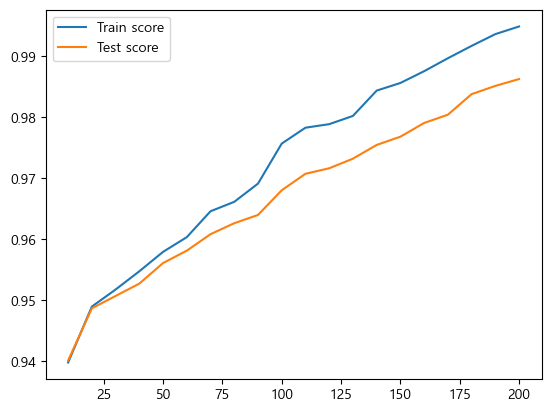

In [24]:
hyperparameters['n_estimators'] = [x * 10 for x in range(1,21)]
df_score_n = run_models_classification(hyperparameters, df_train_x, df_train_y, df_test_x, df_test_y, model_name, 'n_estimators', 1)

In [25]:
df_score_n.round(3)

,n_estimators,TrainScore,TestScore
0,10,0.940,0.940
1,20,0.949,0.949
2,30,0.952,0.951
3,40,0.955,0.953
4,50,0.958,0.956
5,60,0.960,0.958
6,70,0.965,0.961
7,80,0.966,0.963
8,90,0.969,0.964
9,100,0.976,0.968


In [42]:
hyperparameters['n_estimators'] = [100]

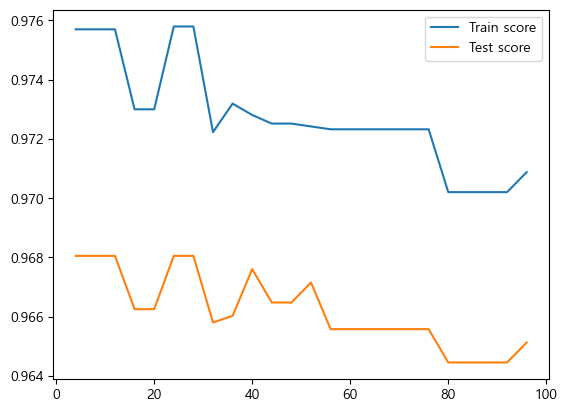

In [43]:
hyperparameters['min_samples_split'] = [x*4 for x in range(1,25)]
df_score_split = run_models_classification(hyperparameters, df_train_x, df_train_y, df_test_x, df_test_y, model_name, 'min_samples_split',1)

In [45]:
df_score_split.round(3)

,min_samples_split,TrainScore,TestScore
0,4,0.976,0.968
1,8,0.976,0.968
2,12,0.976,0.968
3,16,0.973,0.966
4,20,0.973,0.966
5,24,0.976,0.968
6,28,0.976,0.968
7,32,0.972,0.966
8,36,0.973,0.966
9,40,0.973,0.968


In [46]:
hyperparameters['min_samples_split'] = [28]

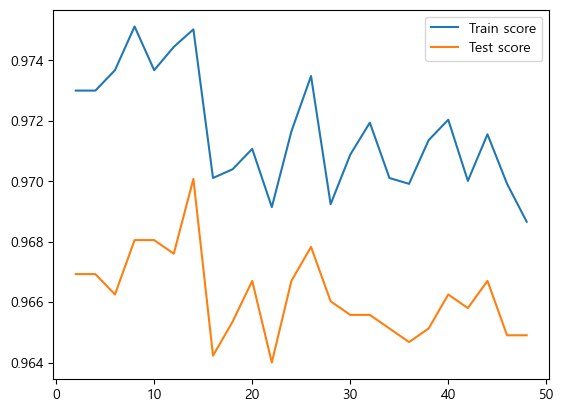

In [47]:
hyperparameters['min_samples_leaf'] = [x * 2 for x in range(1,25)]
df_score = run_models_classification(hyperparameters, df_train_x, df_train_y, df_test_x, df_test_y, model_name, 'min_samples_leaf', 1)

In [48]:
df_score.round(3)

,min_samples_leaf,TrainScore,TestScore
0,2,0.973,0.967
1,4,0.973,0.967
2,6,0.974,0.966
3,8,0.975,0.968
4,10,0.974,0.968
5,12,0.974,0.968
6,14,0.975,0.970
7,16,0.970,0.964
8,18,0.970,0.965
9,20,0.971,0.967


In [49]:
hyperparameters['min_samples_leaf'] = [10]

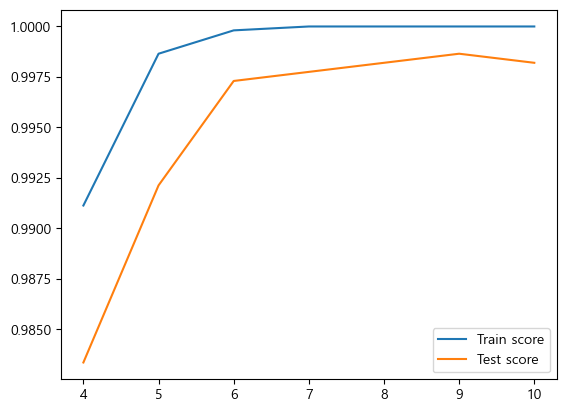

In [50]:
hyperparameters['max_depth'] = [x for x in range(4,11)]
df_score_depth = run_models_classification(hyperparameters, df_train_x, df_train_y, df_test_x, df_test_y, model_name, 'max_depth', 1)

In [51]:
df_score_depth.round(3)

,max_depth,TrainScore,TestScore
0,4,0.991,0.983
1,5,0.999,0.992
2,6,1.000,0.997
3,7,1.000,0.998
4,8,1.000,0.998
5,9,1.000,0.999
6,10,1.000,0.998


In [52]:
hyperparameters['max_depth'] = [6]

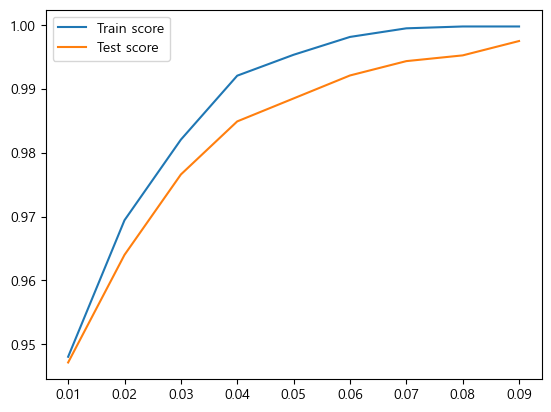

In [53]:
hyperparameters['lr'] = [x for x in np.arange(0.01, 0.1, 0.01)]
df_score_lr = run_models_classification(hyperparameters, df_train_x, df_train_y, df_test_x, df_test_y, model_name, 'lr', 1)

In [55]:
df_score_lr

,lr,TrainScore,TestScore
0,0.01,0.948028,0.947132
1,0.02,0.969434,0.964004
2,0.03,0.982065,0.976603
3,0.04,0.992093,0.984927
4,0.05,0.995372,0.988526
5,0.06,0.998168,0.992126
6,0.07,0.999518,0.994376
7,0.08,0.999807,0.995276
8,0.09,0.999807,0.997525


In [56]:
hyperparameters['lr'] = [0.04]

In [60]:
v_feature_name = df_train_x.columns
gb_final = GradientBoostingClassifier(n_estimators=hyperparameters['n_estimators'][0],
                                     min_samples_leaf = hyperparameters['min_samples_leaf'][0], 
                                     min_samples_split = hyperparameters['min_samples_split'][0],
                                     max_depth = hyperparameters['max_depth'][0],
                                     learning_rate= hyperparameters['lr'][0],
                                     random_state=1986 )

gb_final.fit(df_train_x, df_train_y)
gb_final.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.04,
 'loss': 'log_loss',
 'max_depth': 6,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 10,
 'min_samples_split': 28,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 1986,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

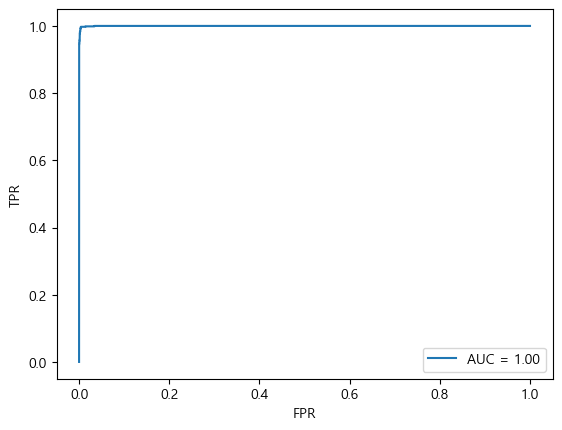

[[9611    0]
 [  82  678]]


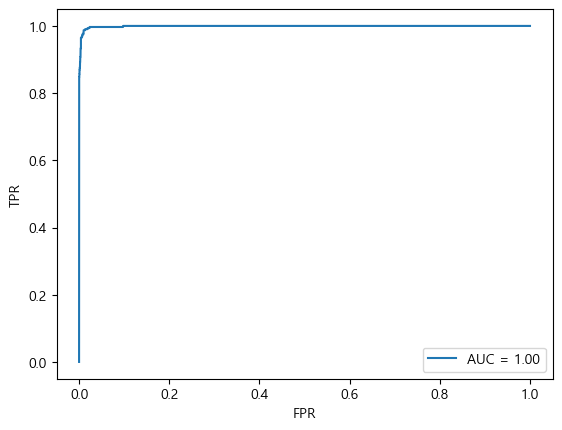

[[4130    0]
 [  67  248]]
             gb_train   gb_test
Accuracy     0.992093  0.984927
Precision    1.000000  1.000000
Recall       0.892105  0.787302
F1_score     0.942976  0.880995
Specificity  1.000000  1.000000


In [61]:
y_pred_train = gb_final.predict(df_train_x)
y_proba_train = gb_final.predict_proba(df_train_x)[:, 1]
y_pred_test = gb_final.predict(df_test_x)
y_proba_test = gb_final.predict_proba(df_test_x)[:, 1]

metric_df_first = pd.DataFrame()
metric_list_train = print_metric(df_train_y, y_pred_train,y_proba_train, "gb_train")
metric_list_test = print_metric(df_test_y, y_pred_test, y_proba_test, "gb_test")

metric_df_first['gb_train'] = metric_list_train
metric_df_first['gb_test'] = metric_list_test

print(metric_df_first)

In [62]:
print("Score on training set: {:.3f}".format(gb_final.score(df_train_x, df_train_y)))
print("Score on test set: {:.3f}".format(gb_final.score(df_test_x, df_test_y)))

Score on training set: 0.992
Score on test set: 0.985
